In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
df=pd.read_csv('REER Data.csv')

In [201]:
df.head()

,Date,REER
0,30-04-2004,75.366766
1,31-05-2004,73.828684
2,30-06-2004,73.374320
3,31-07-2004,72.899197
4,31-08-2004,73.297451


In [202]:
df=df.set_index('Date')

In [203]:
df.isnull().sum()

REER    0
dtype: int64

In [204]:
df.shape

(253, 1)

<Axes: >

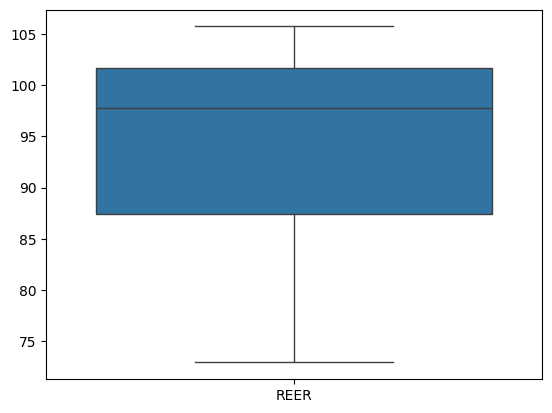

In [205]:
sns.boxplot(df)

<Axes: xlabel='Date'>

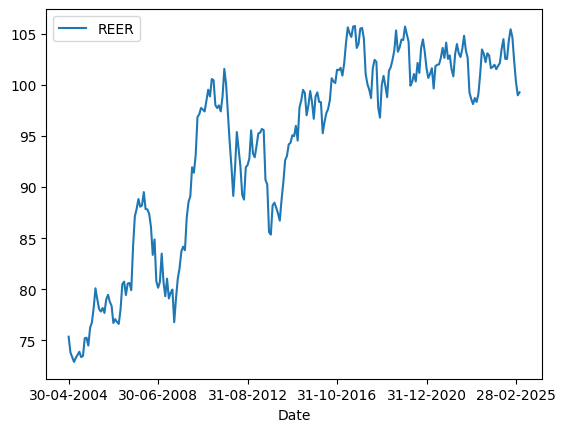

In [206]:
df.plot()

In [207]:
df1=np.log(df)
df2=df1.diff().dropna()

<Axes: xlabel='Date'>

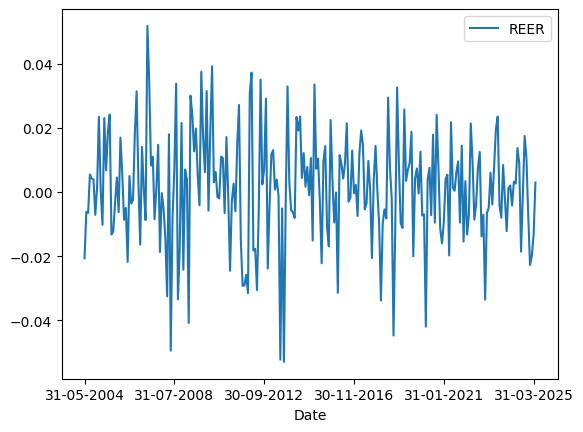

In [208]:
df2.plot()

In [209]:
df2['REER']

Date
31-05-2004   -0.020619
30-06-2004   -0.006173
31-07-2004   -0.006496
31-08-2004    0.005448
30-09-2004    0.004193
                ...   
31-12-2024   -0.007435
31-01-2025   -0.022742
28-02-2025   -0.019902
31-03-2025   -0.013112
30-04-2025    0.002938
Name: REER, Length: 252, dtype: float64

In [210]:
import statsmodels.api as sm
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima.arima import auto_arima

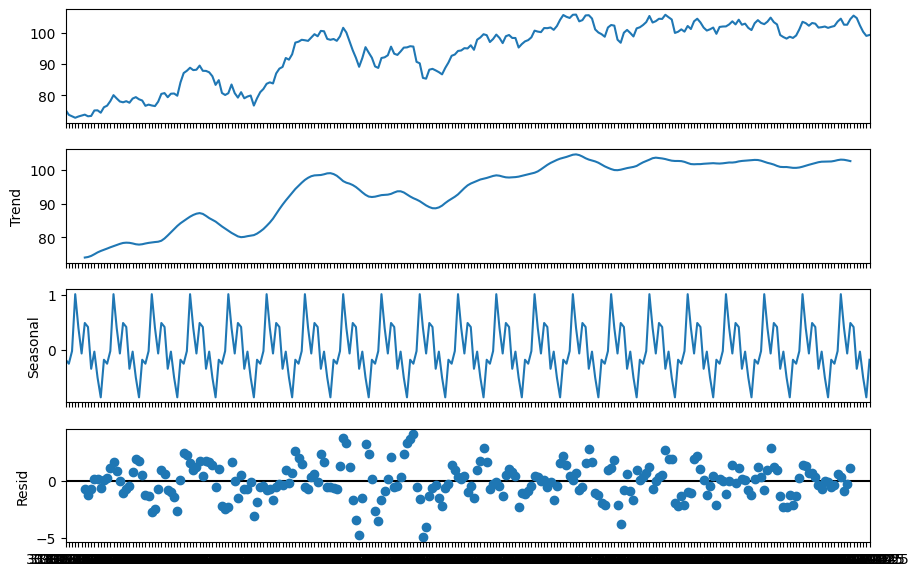

In [211]:
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(df,model='additive',period=12)

fig=result.plot()
fig.set_size_inches(10,6)
plt.show()

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

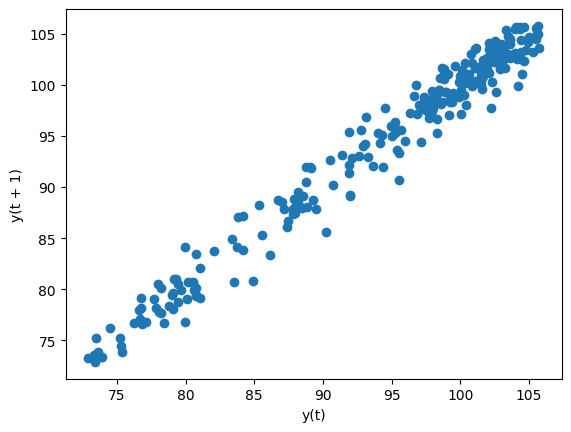

In [212]:
pd.plotting.lag_plot(df['REER'],lag=1)

<Axes: xlabel='y(t)', ylabel='y(t + 12)'>

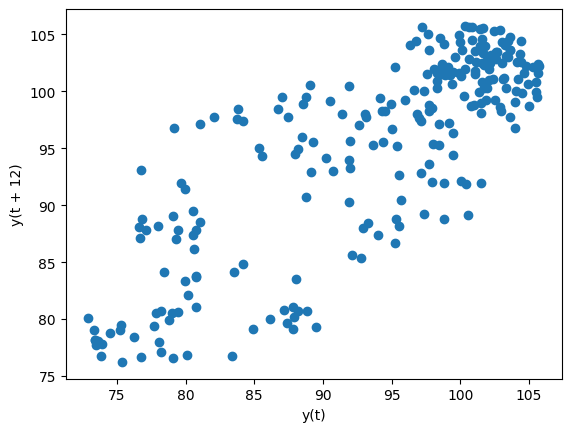

In [213]:
pd.plotting.lag_plot(df['REER'],lag=12)

In [214]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(df1)

print('ADF statistic:',result[0])
print('p-value:',result[1])
print('lags used:',result[2])
for key,value in result [4].items():
  print('critical value{}:{}'.format(key,value))  #non stationary

ADF statistic: -2.1325974550266107
p-value: 0.23161057225204035
lags used: 13
critical value1%:-3.458010773719797
critical value5%:-2.8737103617125186
critical value10%:-2.5732559963936206


In [143]:
max_lag = 12
aic_list = []

for p in range(1, max_lag + 1):
    df1['lag1'] = df1['REER'].shift(1)  # y_{t-1}
    df1['time'] = np.arange(len(df1))

    # Add lagged second differences Δ²y_{t−i}
    for i in range(1, p + 1):
        df1[f'delta_lag{i}'] = df1['REER'].diff().shift(i)

    # Dependent variable: Δ²y_t
    df1['delta2'] =df1['REER'].diff()

    df1.dropna(inplace=True)

    # Regression: Δ²y_t = α + β*y_{t-1} + γ*t + Σ φ_i * Δy_{t-i} + ε_t
    X_cols = ['lag1', 'time'] + [f'delta_lag{i}' for i in range(1, p + 1)]
    X = sm.add_constant(df1[X_cols])
    y = df1['delta2']

    model = OLS(y, X).fit()
    aic_list.append((p, model.aic, model))

# Select best model
best_p, best_aic, best_model = min(aic_list, key=lambda x: x[1])

print(f"\nADF Test on Log-Differenced Series:")
print(f"Best lag (p): {best_p}")
print(f"AIC: {best_aic:.2f}")
print(best_model.summary())

# ADF test statistic = t-stat of lag1 (y_{t-1})
adf_statistic = best_model.tvalues['lag1']
print(f"\nADF Test Statistic (on Δy_t, optimal lag p={best_p}): {adf_statistic:.4f}")



ADF Test on Log-Differenced Series:
Best lag (p): 1
AIC: -707.30
                            OLS Regression Results                            
Dep. Variable:                 delta2   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.7881
Date:                Wed, 02 Jul 2025   Prob (F-statistic):              0.503
Time:                        16:51:35   Log-Likelihood:                 357.65
No. Observations:                 128   AIC:                            -707.3
Df Residuals:                     124   BIC:                            -695.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [168]:
df2

,REER,d2y_lag1,delta2,lag1,time,delta_lag1
Date,,,,,,
30-11-2007,-0.018661,2.370529,-0.010145,-0.008516,2,-0.019486
30-09-2008,-0.033427,1.588263,-0.014765,-0.018661,3,-0.010145
31-03-2009,-0.040767,-0.562836,-0.007340,-0.033427,4,-0.014765
30-06-2009,0.012621,-0.191582,0.053388,-0.040767,5,-0.007340
31-07-2009,0.019743,-0.628355,0.007122,0.012621,6,0.053388
...,...,...,...,...,...,...
31-03-2024,-0.004201,0.491357,-0.000105,-0.004095,62,-0.027566
30-06-2024,0.013674,-0.209459,0.017875,-0.004201,63,-0.000105
31-07-2024,0.008938,1.665307,-0.004736,0.013674,64,0.017875


In [183]:
x=df2.drop(columns=['delta2'])

In [184]:
y.shape,x.shape

((61,), (61, 5))

In [190]:
max_lag = 12
aic_list = []

for p in range(1, max_lag + 1):
    df2['lag1'] = df2['REER'].shift(1)  # y_{t-1}
    df2['time'] = np.arange(len(df2))

    # Add lagged second differences Δ²y_{t−i}
    for i in range(1, p + 1):
        df2[f'delta_lag{i}'] = df2['REER'].diff().shift(i)

    # Dependent variable: Δ²y_t
    df2['delta2'] =df2['REER'].diff()

    df2.dropna(inplace=True)

    # Regression: Δ²y_t = α + β*y_{t-1} + γ*t + Σ φ_i * Δy_{t-i} + ε_t
    X_cols = ['lag1', 'time'] + [f'delta_lag{i}' for i in range(1, p + 1)]

    model = OLS(y, x).fit()
    aic_list.append((p, model.aic, model))

# Select best model
best_p, best_aic, best_model = min(aic_list, key=lambda x: x[1])

print(f"\nADF Test on Log-Differenced Series:")
print(f"Best lag (p): {best_p}")
print(f"AIC: {best_aic:.2f}")
print(best_model.summary())

# ADF test statistic = t-stat of lag1 (y_{t-1})
adf_statistic = best_model.tvalues['lag1']
print(f"\nADF Test Statistic (on Δy_t, optimal lag p={best_p}): {adf_statistic:.4f}")



ADF Test on Log-Differenced Series:
Best lag (p): 1
AIC: -4141.56
                                 OLS Regression Results                                
Dep. Variable:                 delta2   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          2.081e+28
Date:                Wed, 02 Jul 2025   Prob (F-statistic):                        0.00
Time:                        17:12:05   Log-Likelihood:                          2075.8
No. Observations:                  61   AIC:                                     -4142.
Df Residuals:                      56   BIC:                                     -4131.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t

In [215]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(df2)

print('ADF statistic:',result[0])
print('p-value:',result[1])
print('lags used:',result[2])

for key,value in result [4].items():
  print('critical value{}:{}'.format(key,value))  # stationary

ADF statistic: -4.967961805006812
p-value: 2.5672037132522247e-05
lags used: 16
critical value1%:-3.4584868856997004
critical value5%:-2.873918902362675
critical value10%:-2.573367247623359


In [17]:
import pandas as pd
import statsmodels.api as sm

df2.index = pd.to_datetime(df2.index)  

df2['Month'] = df2.index.month
month_dummies = pd.get_dummies(df2['Month'], prefix='month', drop_first=True)

y = df2['REER']  
x = month_dummies  
model = sm.OLS(y, x).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   REER   R-squared (uncentered):                   0.113
Model:                            OLS   Adj. R-squared (uncentered):              0.072
Method:                 Least Squares   F-statistic:                              2.781
Date:                Wed, 02 Jul 2025   Prob (F-statistic):                     0.00202
Time:                        14:46:59   Log-Likelihood:                          682.55
No. Observations:                 252   AIC:                                     -1343.
Df Residuals:                     241   BIC:                                     -1304.
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\ratha\AppData\Local\Temp\ipykernel_28360\1888512226.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df2.index = pd.to_datetime(df2.index)


In [18]:
seasonal_component = model.predict(x)

In [19]:
seasonal_component

Date
2004-05-31   -0.000612
2004-06-30    0.003358
2004-07-31    0.011339
2004-08-31   -0.004711
2004-09-30   -0.003539
                ...   
2024-12-31   -0.007083
2025-01-31    0.000000
2025-02-28   -0.004178
2025-03-31   -0.003664
2025-04-30    0.009094
Length: 252, dtype: float64

In [20]:
y_deseasonalized = y - seasonal_component

In [21]:
y_deseasonalized

Date
2004-05-31   -0.020007
2004-06-30   -0.009531
2004-07-31   -0.017835
2004-08-31    0.010159
2004-09-30    0.007732
                ...   
2024-12-31   -0.000352
2025-01-31   -0.022742
2025-02-28   -0.015724
2025-03-31   -0.009448
2025-04-30   -0.006156
Length: 252, dtype: float64

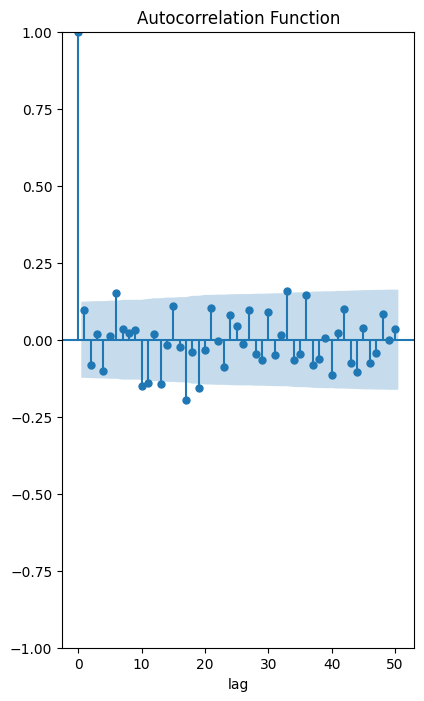

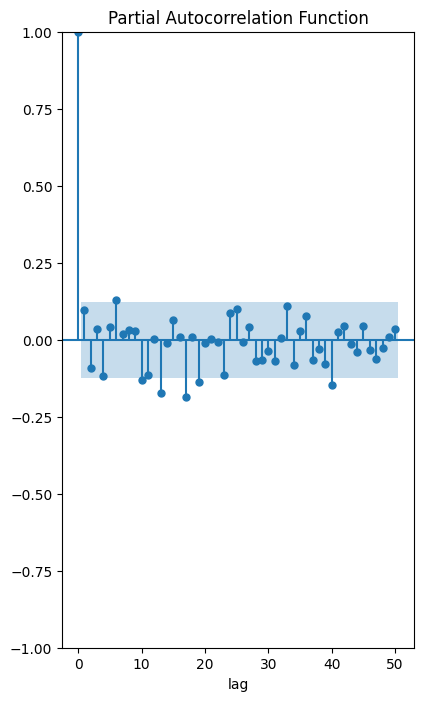

In [217]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plt.figure(figsize=(10,8))
plt.subplot(122)
plot_acf(df2.dropna(),lags=50,ax=plt.gca())
plt.xlabel('lag')
plt.title('Autocorrelation Function')
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(122)
plot_pacf(df2.dropna(),lags=50,ax=plt.gca())
plt.xlabel('lag')
plt.title('Partial Autocorrelation Function')
plt.show()

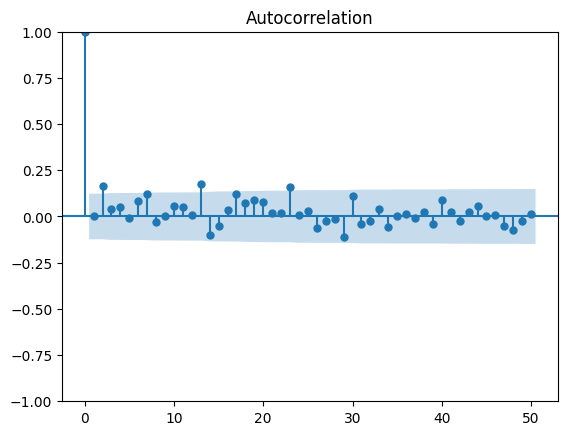

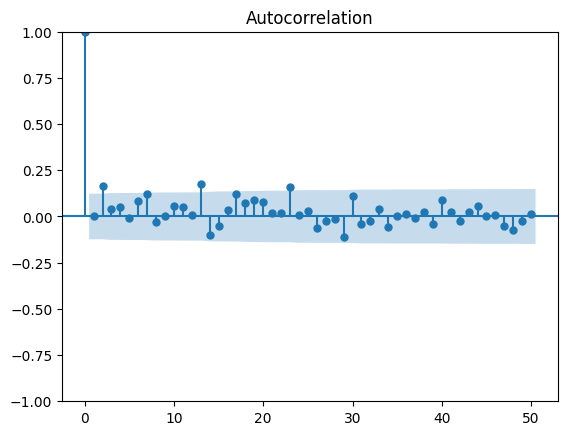

In [223]:
plot_acf(df2**2,lags=50)

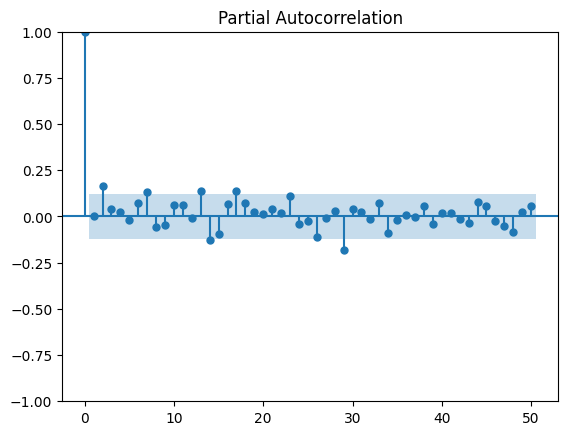

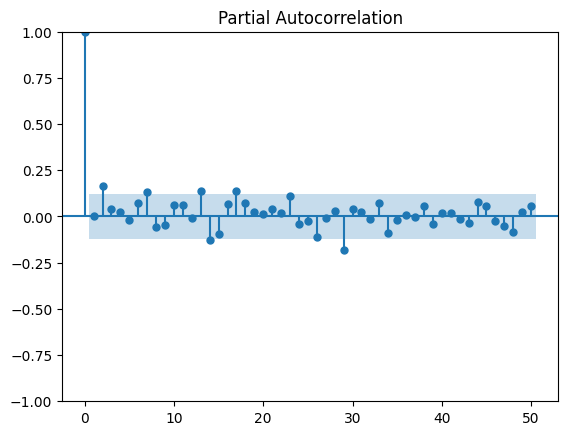

In [224]:
plot_pacf(df2**2,lags=50)

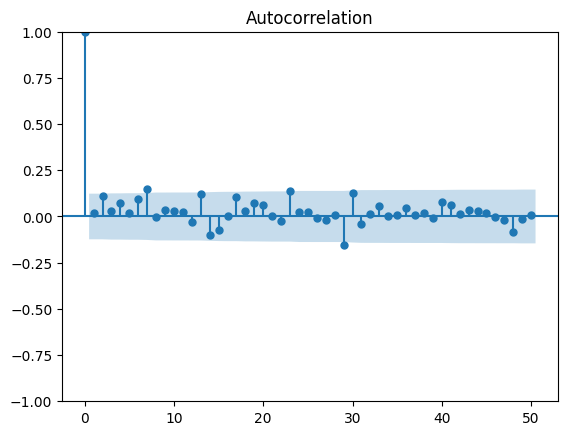

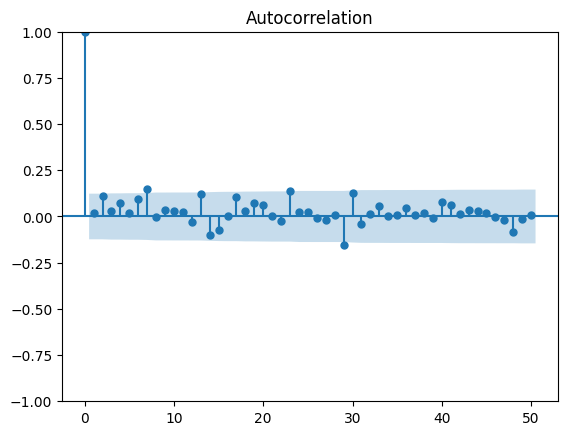

In [225]:
plot_acf(np.abs(df2),lags=50)

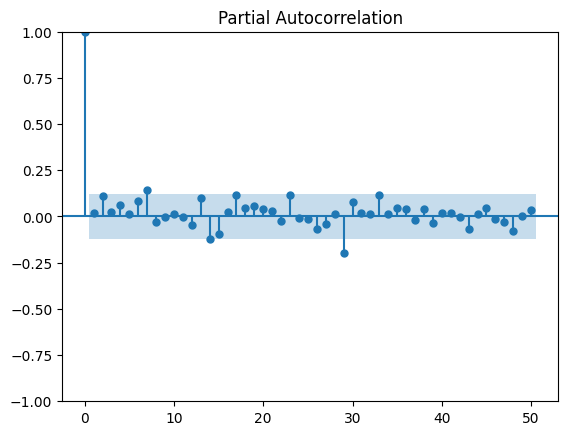

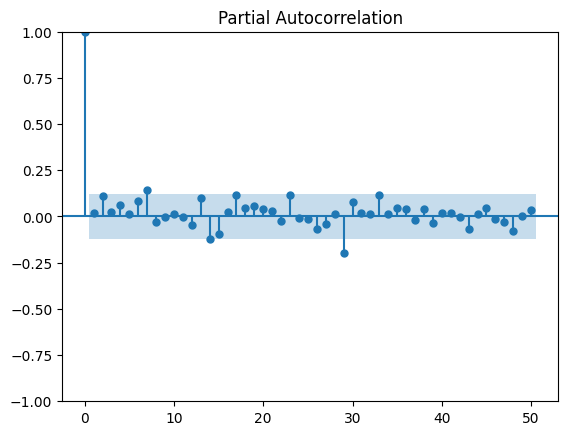

In [226]:
plot_pacf(np.abs(df2),lags=50)

In [27]:
import itertools
import warnings
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def find_best_arima_order(series, p_values, q_values, d=1):
    """
    Evaluate ARIMA models with different (p,q) combinations and return the best order.
    
    Parameters:
        series (pd.Series): Time series data (your REER series)
        p_values (list): List of p values to test (AR order)
        q_values (list): List of q values to test (MA order)
        d (int): Differencing order (fixed as 1)
    
    Returns:
        dict: Best order and corresponding AIC
        pd.DataFrame: Results for all tested combinations
    """
    warnings.filterwarnings("ignore")  # Suppress convergence warnings
    
    best_aic = float("inf")
    best_order = None
    results = []
    
    # Generate all combinations of p and q
    for p, q in itertools.product(p_values, q_values):
        try:
            # This matches your existing model structure
            model = ARIMA(series, order=(p, d, q))
            model_fit = model.fit()
            current_aic = model_fit.aic
            results.append({'p': p, 'q': q, 'AIC': current_aic})
            
            if current_aic < best_aic:
                best_aic = current_aic
                best_order = (p, d, q)
                
        except:
            continue
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='AIC')
    
    return {'best_order': best_order, 'best_aic': best_aic}, results_df

if __name__ == "__main__":

    p_values = [6, 10, 11, 13, 17,19,23,40] 
    q_values = [6,10,11,13,17,19,33]  # Testing around q=6
    
    # Find best ARIMA order
    best_result, all_results = find_best_arima_order(train['REER'], p_values, q_values, d=1)
    
    print(f"Current ARIMA(6,1,6) AIC: {ARIMA(train['REER'], order=(6,1,6)).fit().aic:.2f}")
    print(f"Best ARIMA Order: {best_result['best_order']} with AIC: {best_result['best_aic']:.2f}")
    print("\nTop 5 Models:")
    print(all_results.head().to_string(index=False))

Current ARIMA(6,1,6) AIC: -1038.87
Best ARIMA Order: (6, 1, 19) with AIC: -1045.96

Top 5 Models:
 p  q          AIC
 6 19 -1045.958411
 6 17 -1045.504328
11 11 -1041.589125
10 17 -1040.863798
 6 11 -1040.648879


In [24]:
train_size=int(len(df1)*0.8)
train_size

202

In [26]:
train=df1[:train_size]
test=df1[train_size:]

In [50]:
arima_model=ARIMA(train['REER'],order=(11,1,19))
model_fit=arima_model.fit()

In [51]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   REER   No. Observations:                  202
Model:               ARIMA(11, 1, 19)   Log Likelihood                 549.803
Date:                Wed, 02 Jul 2025   AIC                          -1037.606
Time:                        14:54:15   BIC                           -935.204
Sample:                    04-30-2004   HQIC                          -996.170
                         - 01-31-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0588      2.595     -0.023      0.982      -5.145       5.027
ar.L2         -0.0442      1.371     -0.032      0.974      -2.731       2.643
ar.L3          0.0529      0.381      0.139      0.890      -0.694       0.800
ar.L4         -0.1377      0.321     -0.429      0.668      -0.767       0.491
ar.L5          0.0092      0.357      0.026      0.979      -0.691       0.710
ar.L6          0.2739      0.308      0.889      0.374      -0.330       0.878
ar.L7          0.0027      0.890      0.003      0.998      -1.742       1.748
ar.L8         -0.1566      0.586     -0.267      0.789      -1.304       0.991
ar.L9          0.2613      0.439      0.595      0.552      -0.599       1.122
ar.L10        -0.1855      1.002     -0.185      0.853      -2.150       1.779
ar.L11        -0.1205      0.984     -0.122      0.903      -2.050       1.809
ma.L1          0.1757      2.596      0.068      0.946      -4.912       5.263
ma.L2         -0.0335      1.112     -0.030      0.976      -2.213       2.146
ma.L3         -0.0382      0.368     -0.104      0.917      -0.759       0.682
ma.L4          0.0733      0.292      0.251      0.802      -0.500       0.647
ma.L5          0.1654      0.238      0.695      0.487      -0.301       0.632
ma.L6         -0.1278      0.442     -0.289      0.772      -0.994       0.738
ma.L7          0.1251      0.722      0.173      0.862      -1.290       1.540
ma.L8          0.2252      0.660      0.341      0.733      -1.068       1.519
ma.L9         -0.3489      0.510     -0.684      0.494      -1.349       0.651
ma.L10         0.0137      1.319      0.010      0.992      -2.571       2.598
ma.L11         0.0434      0.721      0.060      0.952      -1.370       1.457
ma.L12        -0.0712      0.144     -0.495      0.620      -0.353       0.211
ma.L13        -0.1159      0.217     -0.534      0.593      -0.541       0.309
ma.L14         0.0025      0.267      0.009      0.993      -0.520       0.525
ma.L15         0.2104      0.238      0.885      0.376      -0.255       0.676
ma.L16         0.1482      0.552      0.269      0.788      -0.933       1.229
ma.L17        -0.2733      0.158     -1.731      0.083      -0.583       0.036
ma.L18        -0.1673      0.837     -0.200      0.842      -1.809       1.474
ma.L19        -0.0880      0.229     -0.384      0.701      -0.538       0.362
sigma2         0.0002   3.15e-05      7.596      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                 7.53
Prob(Q):                              0.54   Prob(JB):                         0.02
Heteroskedasticity (H):               0.80   Skew:                            -0.41
Prob(H) (two-sided):                  0.38   Kurtosis:                         3.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using t

In [52]:
residuals=model_fit.resid

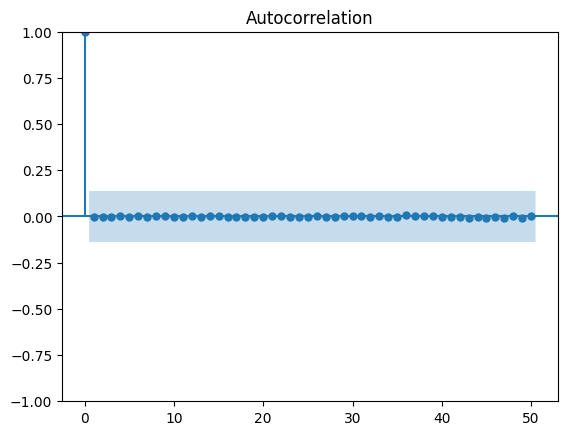

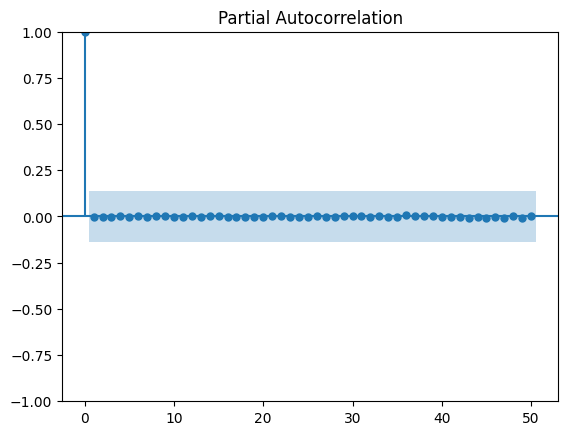

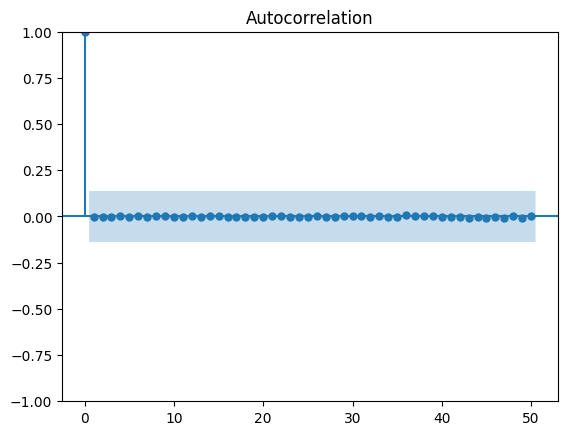

In [53]:
plot_pacf(residuals,lags=50)
plot_acf(residuals,lags=50)

In [54]:
start_pos = len(train)  
end_pos = len(train) + len(test) - 1
predictions = model_fit.predict(start=start_pos, end=end_pos)
predictions=np.exp(predictions)

In [55]:
from sklearn.metrics import mean_squared_error,mean_absolute_percentage_error
import math

In [56]:
mse=mean_squared_error(np.exp(test),predictions)
mape=mean_absolute_percentage_error(np.exp(test),predictions)
rmse=math.sqrt(mse)

In [57]:
mse,mape,rmse

(3.9998540774628433, 0.015677914493893896, 1.9999635190329956)

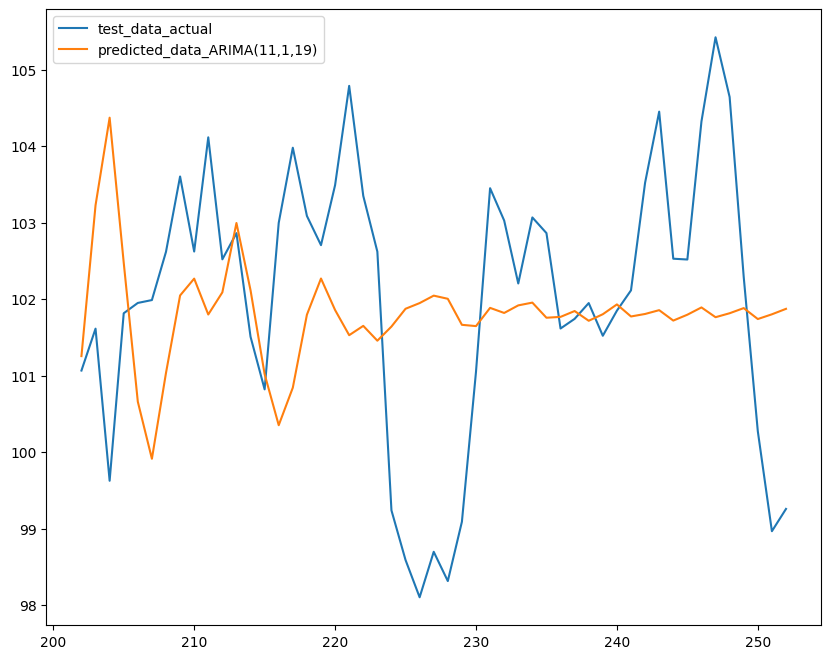

In [59]:
plt.figure(figsize=(10,8))
plt.plot(np.arange(len(train),len(df)),np.exp(test),label='test_data_actual')
plt.plot(np.arange(len(train),len(df)),predictions,label='predicted_data_ARIMA(11,1,19)')
plt.legend()
plt.show()


In [37]:
predictions=np.exp(predictions)

In [38]:
arima_model_1=ARIMA(train['REER'],order=(1,1,1))
model_fit_1=arima_model_1.fit()

In [39]:
model_fit_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   REER   No. Observations:                  202
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 523.462
Date:                Wed, 02 Jul 2025   AIC                          -1040.925
Time:                        14:53:21   BIC                          -1031.015
Sample:                    04-30-2004   HQIC                         -1036.915
                         - 01-31-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5788      0.273     -2.120      0.034      -1.114      -0.044
ma.L1          0.7155      0.227      3.154      0.002       0.271       1.160
sigma2         0.0003   2.83e-05     11.298      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                11.90
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               0.64   Skew:                            -0.41
Prob(H) (two-sided):                  0.07   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [40]:
start_pos = len(train)  
end_pos = len(train) + len(test) - 1
predictions_1= model_fit_1.predict(start=start_pos, end=end_pos, typ='levels')
predictions_1=np.exp(predictions_1)

In [57]:
predictions_1

2021-02-28    100.708699
2021-03-31    100.681832
2021-04-30    100.697382
2021-05-31    100.688382
2021-06-30    100.693591
2021-07-31    100.690576
2021-08-31    100.692321
2021-09-30    100.691311
2021-10-31    100.691895
2021-11-30    100.691557
2021-12-31    100.691753
2022-01-31    100.691640
2022-02-28    100.691705
2022-03-31    100.691667
2022-04-30    100.691689
2022-05-31    100.691676
2022-06-30    100.691684
2022-07-31    100.691680
2022-08-31    100.691682
2022-09-30    100.691681
2022-10-31    100.691681
2022-11-30    100.691681
2022-12-31    100.691681
2023-01-31    100.691681
2023-02-28    100.691681
2023-03-31    100.691681
2023-04-30    100.691681
2023-05-31    100.691681
2023-06-30    100.691681
2023-07-31    100.691681
2023-08-31    100.691681
2023-09-30    100.691681
2023-10-31    100.691681
2023-11-30    100.691681
2023-12-31    100.691681
2024-01-31    100.691681
2024-02-29    100.691681
2024-03-31    100.691681
2024-04-30    100.691681
2024-05-31    100.691681


In [41]:
print(mean_squared_error(np.exp(test),predictions_1))
print(mean_absolute_percentage_error(np.exp(test),predictions_1))
print(rmse)

4.92014893447771
0.019252815241776883
2.0622037337024084


In [42]:
r=model_fit_1.resid

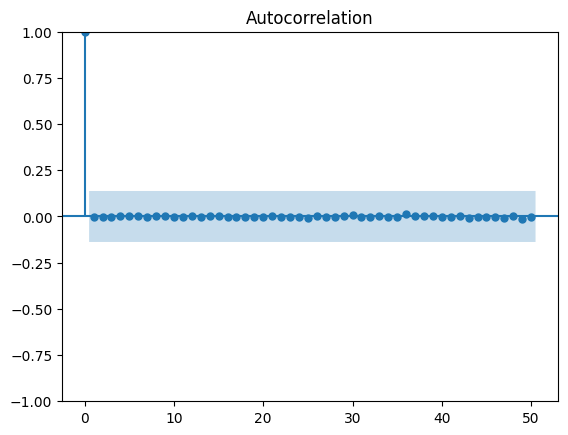

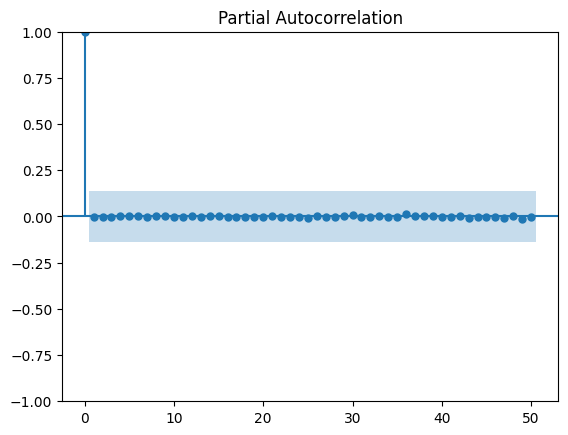

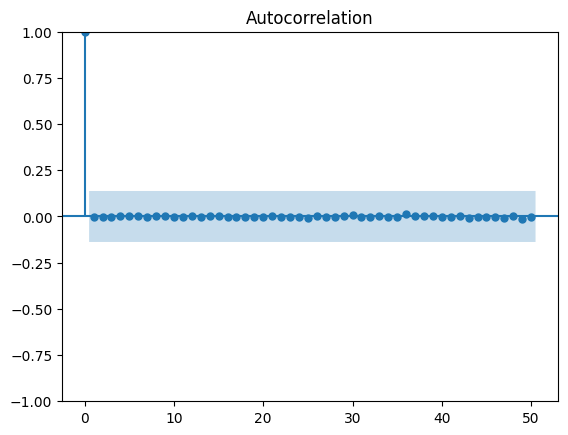

In [43]:
plot_pacf(r,lags=50)
plot_acf(r,lags=50)

In [60]:
df1.index = pd.to_datetime(df1.index)  

df1['Month'] = df1.index.month
month_dummies_1 = pd.get_dummies(df1['Month'], prefix='month', drop_first=True)
exog=month_dummies_1
exog=exog[:202]

C:\Users\ratha\AppData\Local\Temp\ipykernel_20096\2942752497.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1.index = pd.to_datetime(df1.index)


In [61]:
train.index = pd.to_datetime(train.index, dayfirst=True)  
month_dummies.index = pd.to_datetime(month_dummies.index, dayfirst=True)


In [62]:
arima_model_x=ARIMA(train['REER'],order=(6,1,6),exog=exog)
model_fit_x=arima_model_x.fit()

C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA param

In [63]:
model_fit_x.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   REER   No. Observations:                  202
Model:                 ARIMA(6, 1, 6)   Log Likelihood                 539.962
Date:                Mon, 23 Jun 2025   AIC                          -1031.924
Time:                        20:58:08   BIC                           -952.644
Sample:                    04-30-2004   HQIC                          -999.844
                         - 01-31-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_2       -0.0048      0.005     -1.048      0.294      -0.014       0.004
month_3       -0.0100      0.006     -1.647      0.100      -0.022       0.002
month_4      2.77e-05      0.007      0.004      0.997      -0.014       0.014
month_5       -0.0049      0.007     -0.662      0.508      -0.019       0.010
month_6       -0.0040      0.007     -0.545      0.586      -0.018       0.010
month_7        0.0069      0.007      0.949      0.342      -0.007       0.021
month_8     1.977e-05      0.008      0.003      0.998      -0.015       0.015
month_9       -0.0065      0.008     -0.824      0.410      -0.022       0.009
month_10       0.0010      0.008      0.133      0.894      -0.014       0.016
month_11       0.0008      0.007      0.125      0.900      -0.012       0.014
month_12      -0.0052      0.004     -1.221      0.222      -0.014       0.003
ar.L1          0.0904     62.598      0.001      0.999    -122.599     122.779
ar.L2         -0.0094     36.588     -0.000      1.000     -71.721      71.702
ar.L3         -0.0226     19.022     -0.001      0.999     -37.306      37.260
ar.L4         -0.0364      8.364     -0.004      0.997     -16.429      16.356
ar.L5          0.0517      6.371      0.008      0.994     -12.436      12.539
ar.L6          0.0431      6.373      0.007      0.995     -12.447      12.533
ma.L1          0.0889     62.615      0.001      0.999    -122.634     122.812
ma.L2         -0.0318     25.369     -0.001      0.999     -49.754      49.690
ma.L3         -0.0317     10.917     -0.003      0.998     -21.429      21.366
ma.L4         -0.0068      7.681     -0.001      0.999     -15.061      15.047
ma.L5          0.0809      3.268      0.025      0.980      -6.324       6.486
ma.L6          0.0340      3.497      0.010      0.992      -6.820       6.888
sigma2         0.0003   2.91e-05      9.271      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 6.55
Prob(Q):                              0.73   Prob(JB):                         0.04
Heteroskedasticity (H):               0.73   Skew:                            -0.28
Prob(H) (two-sided):                  0.19   Kurtosis:                         3.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [64]:
last_train_date = train.index[-1] 
future_dates = pd.date_range(
    start=last_train_date + pd.offsets.MonthEnd(1),  
    periods=len(test),  
    freq='M'  
)
future_dummies = pd.get_dummies(
    future_dates.month, 
    prefix='month', 
    drop_first=True
)

future_dummies = future_dummies.reindex(columns=month_dummies.columns)
start_pos = len(train)
end_pos = len(train) + len(test) - 1
predictions_x = model_fit_x.predict(
    start=start_pos,
    end=end_pos,
    exog=future_dummies,  
    typ='levels'
)
predictions_x= np.exp(predictions_x)  

C:\Users\ratha\AppData\Local\Temp\ipykernel_20096\3267012322.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [65]:
predictions_x

2021-02-28    100.443618
2021-03-31    100.297329
2021-04-30    101.302240
2021-05-31    100.672330
2021-06-30    100.484402
2021-07-31    101.449467
2021-08-31    100.782307
2021-09-30    100.152927
2021-10-31    100.921031
2021-11-30    100.888025
2021-12-31    100.256950
2022-01-31    100.774563
2022-02-28    100.290096
2022-03-31     99.780515
2022-04-30    100.783421
2022-05-31    100.288899
2022-06-30    100.376136
2022-07-31    101.470936
2022-08-31    100.779238
2022-09-30    100.119926
2022-10-31    100.879298
2022-11-30    100.861644
2022-12-31    100.252265
2023-01-31    100.777297
2023-02-28    100.290650
2023-03-31     99.778045
2023-04-30    100.780141
2023-05-31    100.287143
2023-06-30    100.375982
2023-07-31    101.471252
2023-08-31    100.779322
2023-09-30    100.119723
2023-10-31    100.879044
2023-11-30    100.861526
2023-12-31    100.252268
2024-01-31    100.777330
2024-02-29    100.290657
2024-03-31     99.778027
2024-04-30    100.780121
2024-05-31    100.287135


In [66]:
res_x=model_fit_x.resid

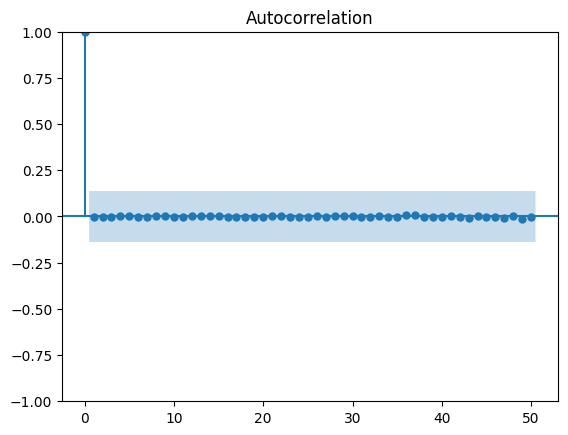

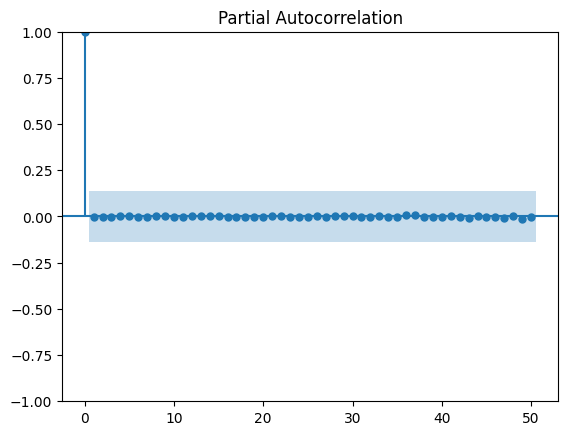

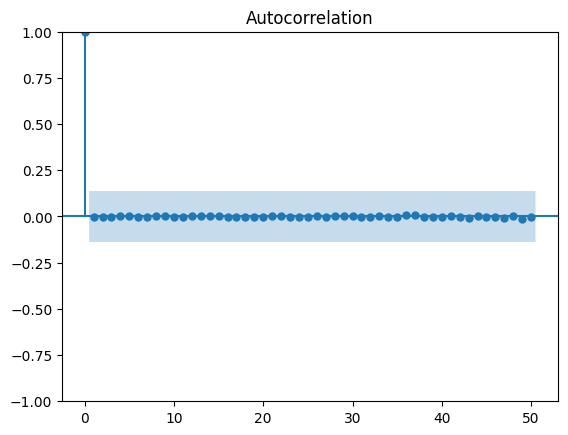

In [67]:
plot_pacf(res_x,lags=50)
plot_acf(res_x,lags=50)

In [68]:
mse=mean_squared_error(np.exp(test),predictions_x)
mape=mean_absolute_percentage_error(np.exp(test),predictions_x)

In [69]:
mse,mape

(4.99309039164685, 0.019403453777889875)

In [159]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA


history = train['REER'].values.astype(float)
prediction = []

for t in range(len(test)):
    model = ARIMA(history, order=(6, 1, 6))  
    model_fit = model.fit(method_kwargs={"maxiter": 200})
    forecast = model_fit.forecast(steps=1)
    prediction.append(forecast[0])
    history = np.append(history, test['REER'].iloc[t])
    
print(prediction)

prediction=np.exp(prediction)

C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\base\model

[4.616729948811739, 4.623901782634445, 4.629258478394592, 4.592751875348378, 4.609991773880631, 4.618807878054149, 4.622517592873613, 4.629182766330972, 4.648114987589378, 4.635554501719825, 4.650620950164525, 4.632558141351081, 4.635055268622763, 4.610377122007745, 4.603145843270761, 4.633397416412284, 4.639879606352358, 4.637844382817395, 4.637131049467712, 4.641626757882783, 4.651546992226327, 4.640118578346793, 4.6296985932208745, 4.587697845244822, 4.589170620778909, 4.5848001742083575, 4.585713785119145, 4.589906973637892, 4.58987214599422, 4.616178638457905, 4.641459410812466, 4.631577824832228, 4.629746124557886, 4.644874816223912, 4.635222146595611, 4.626401472633034, 4.6233374437311925, 4.620276613137268, 4.61742595505687, 4.621103404839054, 4.619521881290273, 4.642554964554838, 4.654644333362766, 4.631337576973174, 4.634583826987831, 4.6505947799640905, 4.6555477940756145, 4.6494121709528144, 4.6227775152426105, 4.6034466180816525, 4.596963019537781]


C:\Users\ratha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [160]:
prediction

array([101.16268351, 101.89081336, 102.43807589,  98.76584784,
       100.48332305, 101.37311096, 101.7498747 , 102.43032039,
       104.38802727, 103.08506299, 104.64994781, 102.77664529,
       103.03361236, 100.52205157,  99.79777049, 102.86293938,
       103.53188225, 103.321386  , 103.2477097 , 103.71292625,
       104.74690295, 103.55662643, 102.48317033,  98.26794155,
        98.41277479,  97.98360553,  98.07316533,  98.48526801,
        98.48183806, 101.10692684, 103.69557165, 102.67594102,
       102.48804161, 104.05033956, 103.05080784, 102.1458274 ,
       101.83332863, 101.5221106 , 101.23311788, 101.60608294,
       101.44551753, 103.80923797, 105.0718428 , 102.65127631,
       102.98504948, 104.64720913, 105.16681398, 104.52352555,
       101.77632521,  99.82779166,  99.18264204])

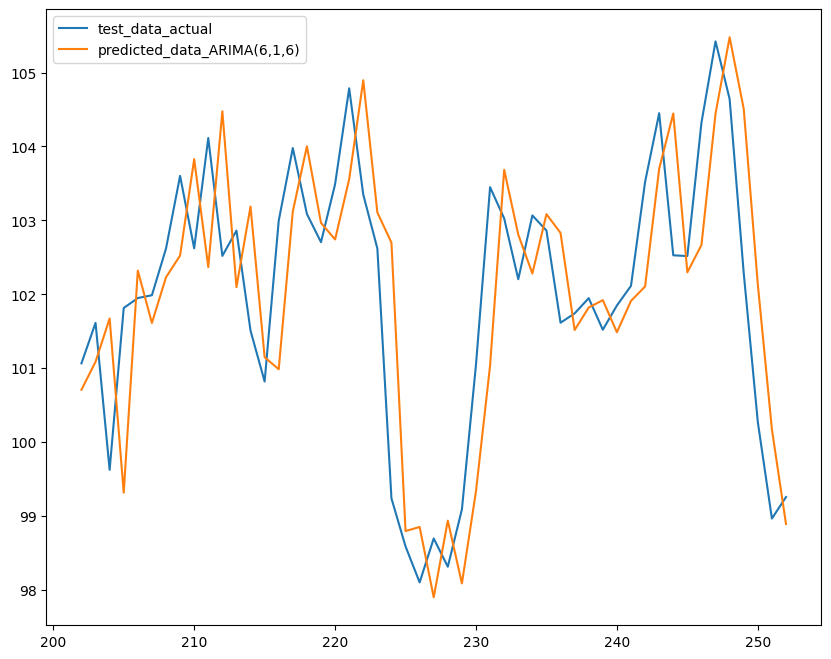

In [153]:
plt.figure(figsize=(10,8))
plt.plot(np.arange(len(train),len(df)),np.exp(test),label='test_data_actual')
plt.plot(np.arange(len(train),len(df)),prediction,label='predicted_data_ARIMA(6,1,6)')
plt.legend()
plt.show()


In [161]:
print(mean_squared_error(np.exp(test),prediction))
print(mean_absolute_percentage_error(np.exp(test),prediction))
print(rmse)

1.9625144620004271
0.010614990554818462
2.2224246426779874


In [155]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA


history = train['REER'].values.astype(float)
prediction = []

for t in range(len(test)):
    model = ARIMA(history, order=(1, 1, 1))  
    model_fit = model.fit(method_kwargs={"maxiter": 200})
    forecast = model_fit.forecast(steps=1)
    prediction.append(forecast[0])
    history = np.append(history, test['REER'].iloc[t])
    
print(prediction)

prediction=np.exp(prediction)

[4.6122321858314255, 4.615989253604687, 4.621764764893835, 4.5983158793074175, 4.628116348631413, 4.621167760822246, 4.6272321570555235, 4.63010587181081, 4.642739691683399, 4.628581884105463, 4.648961161551506, 4.625923316653935, 4.636553815313567, 4.616595933664521, 4.61498679024905, 4.635913939729415, 4.644414665621929, 4.634410300128102, 4.632222441642247, 4.6401270107643215, 4.652968713765233, 4.635768999451994, 4.631802671818042, 4.593074872517892, 4.5936356636957845, 4.583965099053535, 4.59450194318197, 4.585878300034386, 4.59852425753039, 4.615480944255253, 4.641350854647144, 4.632863752812175, 4.627732004398525, 4.635549499950188, 4.633083725276088, 4.620229236051, 4.623223281747978, 4.62420216997691, 4.619930336386249, 4.6241009294812185, 4.626014844260527, 4.641487902289464, 4.648676725827377, 4.627886635422554, 4.6314913982635355, 4.648663595158243, 4.658497245047132, 4.6492700713446, 4.626291680960089, 4.606905499881602, 4.594038614900739]


In [156]:
print(mean_squared_error(np.exp(test),prediction))
print(mean_absolute_percentage_error(np.exp(test),prediction))
print(rmse)

1.6082729708668875
0.01010508361073592
2.2224246426779874


In [157]:
residuals_rf=model_fit.resid

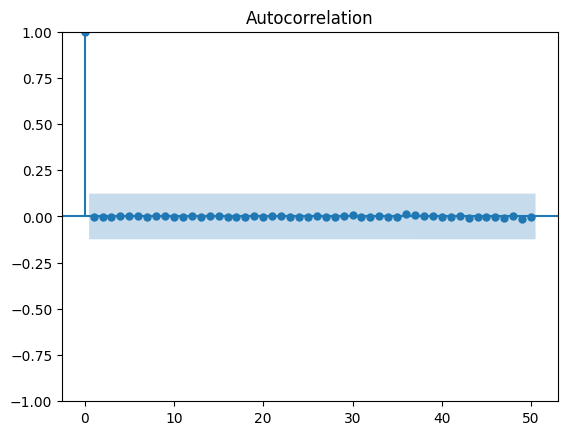

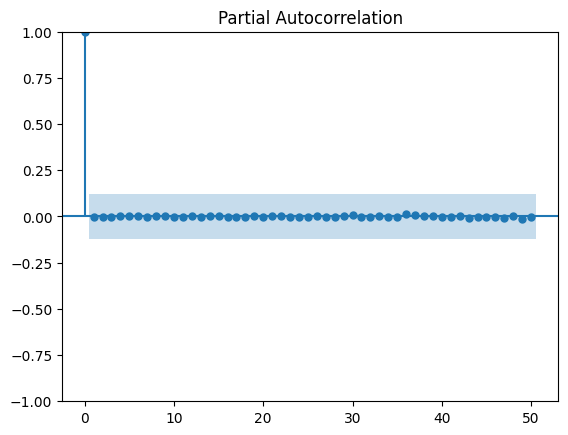

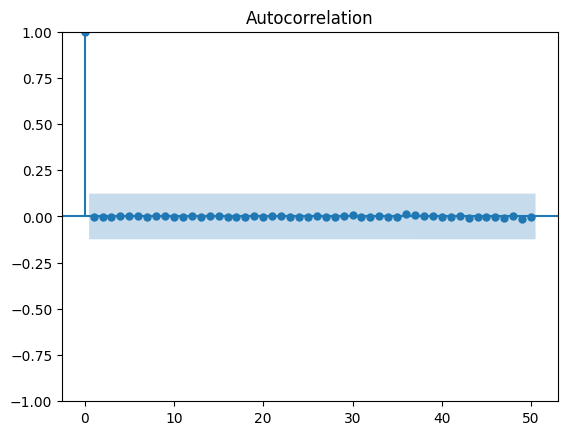

In [158]:
plot_pacf(residuals_rf,lags=50)
plot_acf(residuals_rf,lags=50)


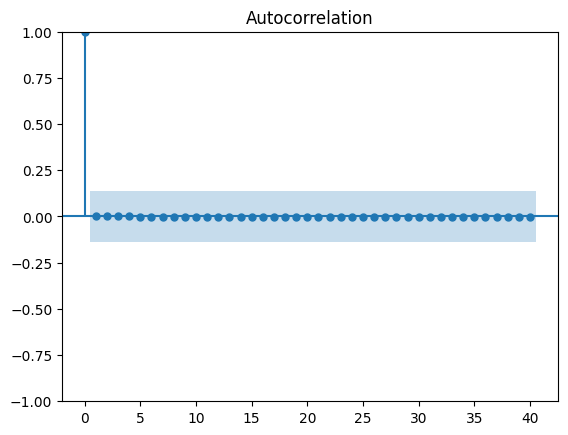

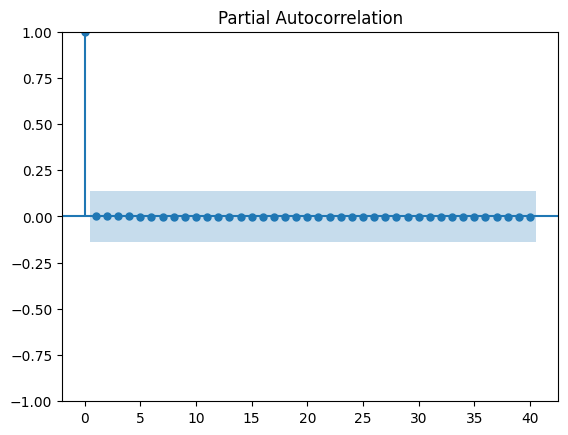

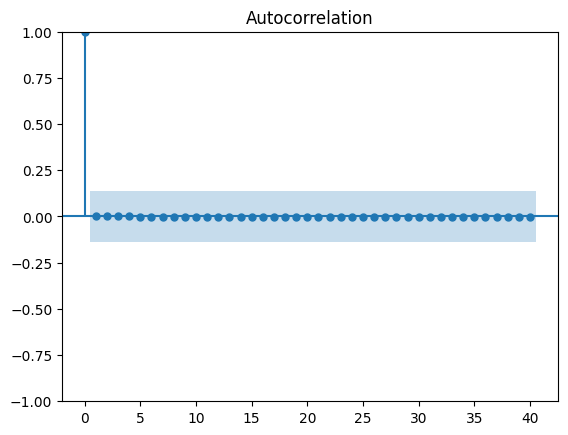

In [94]:
plot_pacf(r**2,lags=40)
plot_acf(r**2,lags=40)

In [96]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch
test_result = het_arch(r)
print(f"LM Statistic: {test_result[0]}")
print(f"P-value: {test_result[1]}")
print(f"F Statistic: {test_result[2]}")
print(f"F P-value: {test_result[3]}")

# Or with specified lags
test_result = het_arch(r, maxlag=5)

LM Statistic: 9.967510934959428
P-value: 0.4433482856565424
F Statistic: 0.9910975169839271
F P-value: 0.4528354066785286


C:\Users\ratha\AppData\Local\Temp\ipykernel_20096\630209823.py:10: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  test_result = het_arch(r, maxlag=5)


In [838]:
train_season=y_deseasonalized[:train_size]
test_season=y_deseasonalized[train_size:]

In [839]:
model=ARIMA(train_season,order=(11,1,19))
model=model.fit()

In [840]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  202
Model:               ARIMA(11, 1, 19)   Log Likelihood                 549.391
Date:                Tue, 24 Jun 2025   AIC                          -1036.783
Time:                        03:26:58   BIC                           -934.380
Sample:                    05-31-2004   HQIC                          -995.346
                         - 02-28-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0133     28.590     -0.035      0.972     -57.048      55.021
ar.L2         -1.0812     31.969     -0.034      0.973     -63.738      61.576
ar.L3         -1.0646     33.507     -0.032      0.975     -66.737      64.608
ar.L4         -1.1899     33.678     -0.035      0.972     -67.198      64.818
ar.L5         -0.9940     37.168     -0.027      0.979     -73.841      71.853
ar.L6         -0.7419     32.125     -0.023      0.982     -63.706      62.222
ar.L7         -0.5773     24.272     -0.024      0.981     -48.149      46.994
ar.L8         -0.4889     18.999     -0.026      0.979     -37.727      36.749
ar.L9         -0.2146     15.966     -0.013      0.989     -31.508      31.078
ar.L10        -0.1633      7.863     -0.021      0.983     -15.575      15.248
ar.L11         0.0250      5.499      0.005      0.996     -10.753      10.803
ma.L1          0.1593     28.587      0.006      0.996     -55.870      56.188
ma.L2          0.0908      7.617      0.012      0.990     -14.839      15.021
ma.L3          0.0613      2.703      0.023      0.982      -5.237       5.359
ma.L4          0.1413      2.434      0.058      0.954      -4.629       4.911
ma.L5          0.0427      4.250      0.010      0.992      -8.288       8.373
ma.L6         -0.1033      1.841     -0.056      0.955      -3.711       3.505
ma.L7          0.0339      2.840      0.012      0.990      -5.532       5.600
ma.L8          0.0358      0.800      0.045      0.964      -1.532       1.604
ma.L9         -0.2804      1.196     -0.234      0.815      -2.624       2.063
ma.L10        -0.2029      7.929     -0.026      0.980     -15.744      15.338
ma.L11        -0.2522      6.651     -0.038      0.970     -13.289      12.784
ma.L12        -0.0669      7.707     -0.009      0.993     -15.172      15.039
ma.L13        -0.1852      2.731     -0.068      0.946      -5.539       5.168
ma.L14        -0.0466      5.580     -0.008      0.993     -10.983      10.890
ma.L15         0.1179      1.911      0.062      0.951      -3.628       3.864
ma.L16         0.1013      3.270      0.031      0.975      -6.308       6.511
ma.L17        -0.2986      3.172     -0.094      0.925      -6.516       5.919
ma.L18        -0.1671      8.302     -0.020      0.984     -16.438      16.104
ma.L19         0.0102      5.727      0.002      0.999     -11.215      11.236
sigma2         0.0002   3.03e-05      7.896      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 6.90
Prob(Q):                              0.91   Prob(JB):                         0.03
Heteroskedasticity (H):               0.83   Skew:                            -0.37
Prob(H) (two-sided):                  0.43   Kurtosis:                         3.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using t

In [841]:
start_pos = len(train_season)  
end_pos = len(train_season) + len(test_season) - 1
model_pred= model.predict(start=start_pos, end=end_pos, typ='levels',dynamic=False)


In [842]:
sc=seasonal_component[len(train_season):]
model_pred=np.exp(model_pred+sc)

In [843]:
model_pred,sc

(2021-03-31    1.007109
 2021-04-30    1.024149
 2021-05-31    0.986794
 2021-06-30    0.985591
 2021-07-31    1.003770
 2021-08-31    1.007191
 2021-09-30    1.001523
 2021-10-31    1.000666
 2021-11-30    1.004364
 2021-12-31    0.998292
 2022-01-31    1.008808
 2022-02-28    0.991341
 2022-03-31    0.982411
 2022-04-30    0.999723
 2022-05-31    1.004420
 2022-06-30    1.016042
 2022-07-31    1.016940
 2022-08-31    0.993759
 2022-09-30    0.990651
 2022-10-31    1.005409
 2022-11-30    1.002354
 2022-12-31    0.994810
 2023-01-31    0.999840
 2023-02-28    0.994804
 2023-03-31    0.996942
 2023-04-30    1.010848
 2023-05-31    1.001145
 2023-06-30    1.002788
 2023-07-31    1.010086
 2023-08-31    0.994231
 2023-09-30    0.996963
 2023-10-31    1.008598
 2023-11-30    1.002348
 2023-12-31    0.993069
 2024-01-31    0.999728
 2024-02-29    0.995963
 2024-03-31    0.996556
 2024-04-30    1.009442
 2024-05-31    0.999352
 2024-06-30    1.003393
 2024-07-31    1.011606
 2024-08-31    0

In [811]:
sc=seasonal_component[len(train_season):] 

In [848]:
#(model_pred.values)*100,np.exp(test).values ???? Why

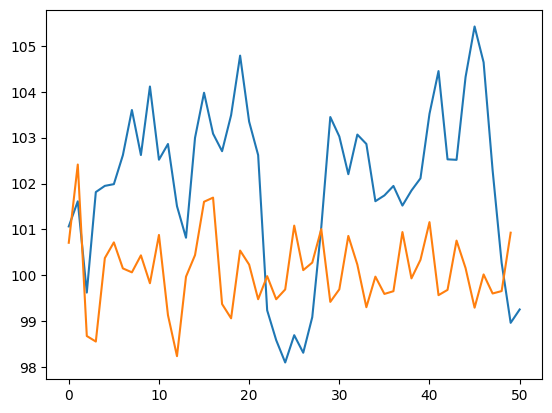

In [847]:
plt.plot(np.exp(test).values)
plt.plot((model_pred.values)*100)

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                   REER   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                254.144
Distribution:                  Normal   AIC:                          -502.289
Method:            Maximum Likelihood   BIC:                          -492.364
                                        No. Observations:                  202
Date:                Wed, Jul 02 2025   Df Residuals:                      201
Time:                        21:34:13   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             4.5879  4.844e-03    947.118      0.000 [  4.578,  4.59

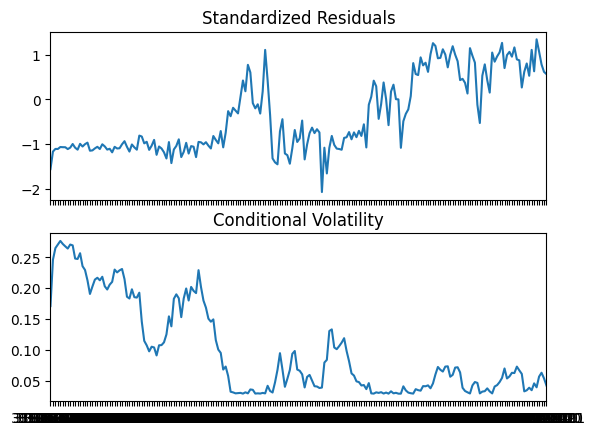

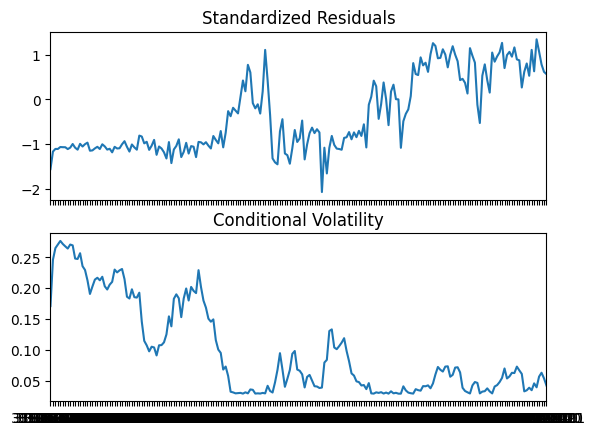

In [231]:
from arch import arch_model
# Fit ARCH(1) model
model = arch_model(train, vol='ARCH', p=1)
model_fit = model.fit(disp='off')

# Print model summary
print(model_fit.summary())

# Plot conditional volatility
model_fit.plot()


In [256]:
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import numpy as np

# Step 1: Fit ARIMA model on train data
series = df1['REER'].dropna()

# train and test split
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# ARIMA model
arima_model = ARIMA(train, order=(1, 1, 1))
arima_result = arima_model.fit()

# Step 2: Forecast mean values on test data
start_pos = len(train)
end_pos = len(train) + len(test) - 1
mean_forecast = arima_result.predict(start=start_pos, end=end_pos, typ='levels', dynamic=False)

# Step 3: Fit ARCH model on ARIMA residuals
residuals = arima_result.resid.dropna()
arch = arch_model(residuals, vol='ARCH', p=1, mean='Zero')
arch_result = arch.fit(disp='off')

# Step 4: Forecast volatility (ARCH)
horizon = len(test)
vol_forecast = arch_result.forecast(horizon=horizon)

# Extract 1-step-ahead variances for all test points
variance_forecast = vol_forecast.variance.values[-1]  # last row gives h-step forecast
std_forecast = np.sqrt(variance_forecast)

# Step 5: Construct prediction intervals
upper_95 = mean_forecast + 1.96 * std_forecast
lower_95 = mean_forecast - 1.96 * std_forecast

# Output
for i in range(horizon):
    print(f"Step {i+1}: Mean={mean_forecast.iloc[i]:.4f}, StdDev={std_forecast[i]:.4f}, CI=[{lower_95.iloc[i]:.4f}, {upper_95.iloc[i]:.4f}]")


Step 1: Mean=4.6122, StdDev=0.0173, CI=[4.5783, 4.6462]
Step 2: Mean=4.6120, StdDev=0.0214, CI=[4.5701, 4.6538]
Step 3: Mean=4.6121, StdDev=0.0235, CI=[4.5661, 4.6582]
Step 4: Mean=4.6120, StdDev=0.0247, CI=[4.5636, 4.6605]
Step 5: Mean=4.6121, StdDev=0.0255, CI=[4.5622, 4.6620]
Step 6: Mean=4.6121, StdDev=0.0259, CI=[4.5613, 4.6628]
Step 7: Mean=4.6121, StdDev=0.0262, CI=[4.5608, 4.6633]
Step 8: Mean=4.6121, StdDev=0.0263, CI=[4.5605, 4.6637]
Step 9: Mean=4.6121, StdDev=0.0264, CI=[4.5603, 4.6639]
Step 10: Mean=4.6121, StdDev=0.0265, CI=[4.5601, 4.6640]
Step 11: Mean=4.6121, StdDev=0.0265, CI=[4.5601, 4.6641]
Step 12: Mean=4.6121, StdDev=0.0265, CI=[4.5600, 4.6641]
Step 13: Mean=4.6121, StdDev=0.0266, CI=[4.5600, 4.6641]
Step 14: Mean=4.6121, StdDev=0.0266, CI=[4.5600, 4.6641]
Step 15: Mean=4.6121, StdDev=0.0266, CI=[4.5600, 4.6642]
Step 16: Mean=4.6121, StdDev=0.0266, CI=[4.5600, 4.6642]
Step 17: Mean=4.6121, StdDev=0.0266, CI=[4.5600, 4.6642]
Step 18: Mean=4.6121, StdDev=0.0266, CI=

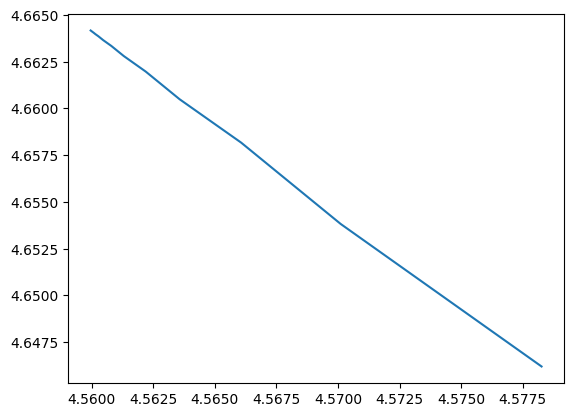

In [261]:
plt.plot(lower_95,upper_95)

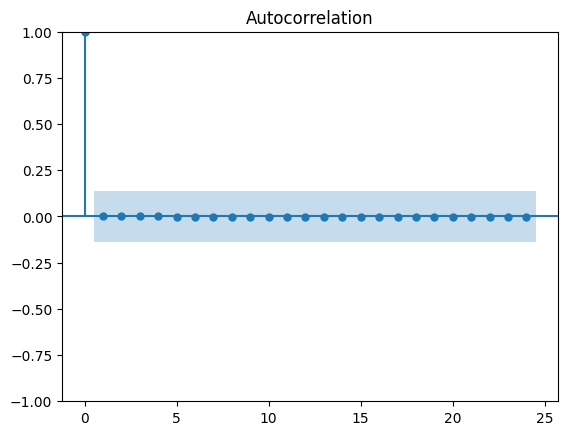

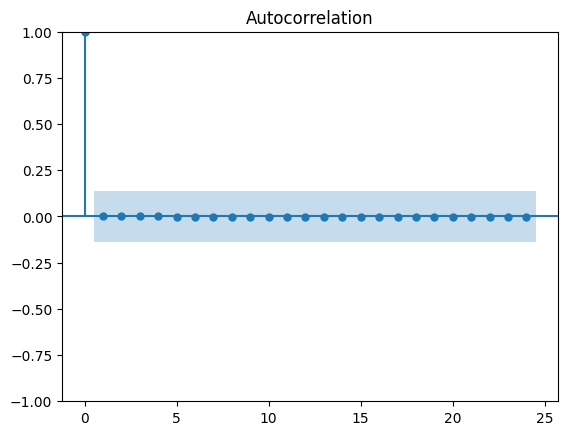

In [264]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = arima_result.resid.dropna()
plot_acf(residuals**2)


In [265]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residuals)
print(f"LM Stat: {arch_test[0]}, p-value: {arch_test[1]}")


LM Stat: 9.967510934959428, p-value: 0.4433482856565424
